In [8]:
import anomalib
import torch
import open_clip
import sys
import os
from pathlib import Path
import torch
from anomalib.models import Patchcore
from anomalib.data import Folder
from anomalib.engine import Engine
from anomalib.utils.normalization import NormalizationMethod
from torchvision import transforms
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="wandb")
print(anomalib.__version__)
print(open_clip.__version__)
print(sys.executable)
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.1.0
3.1.0
d:\Baggage_XRay\.venv\Scripts\python.exe
2.8.0+cu126
12.6
True


In [9]:
import os
from pathlib import Path
from anomalib.data.utils import read_image

dataset_path = "D:/Baggage_XRay"
train_folder = os.path.join(dataset_path, "train1")
val_folder = os.path.join(dataset_path, "val")
test_folder = os.path.join(dataset_path, "test1")


def count_images(folder):
    count = 0
    for root, dirs, files in os.walk(folder):
        for file in files:
            if file.lower().endswith((".png", ".jpg", ".jpeg")):
                count += 1
    return count

print("Number of training images:", count_images(train_folder))
print("Number of validation images:", count_images(val_folder))
print("Number of test images:", count_images(test_folder))



Number of training images: 10532
Number of validation images: 1395
Number of test images: 2775


In [10]:
from anomalib.pre_processing import PreProcessor
from torchvision.transforms.v2 import Compose, Resize, ToTensor, Normalize

transform = Compose([
    Resize((256, 256)),  # ✅ 一定要固定大小
    ToTensor(),
    Normalize(mean=[0.43, 0.48, 0.45], std=[0.23, 0.22, 0.25]),
])

pre_processor = PreProcessor(transform=transform)

d:\Baggage_XRay\.venv\lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [15]:
from anomalib.data import Folder
from anomalib.data.utils import TestSplitMode, ValSplitMode
# from anomalib import TaskType

train_data = "D:/Baggage_XRay/train"  
test_data = "D:/Baggage_XRay/test"     

datamodule = Folder(
    name="normal_dataset",
    root="D:/Baggage_XRay",
    normal_dir="train/Normal",
    normal_test_dir="test/Normal",
    abnormal_dir=None,
    seed=42,
    test_split_mode=TestSplitMode.FROM_DIR,
    val_split_mode=ValSplitMode.FROM_TEST,
    val_split_ratio=0.2,
    train_batch_size=16,
    eval_batch_size=16,
    num_workers=2,
)
datamodule.setup()

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
from anomalib.models import Patchcore
from anomalib.engine import Engine
model = Patchcore(
    backbone="wide_resnet50_2",
    layers=["layer2", "layer3"],
    coreset_sampling_ratio=0.1
)

In [13]:
engine = Engine(
    accelerator="gpu",
    devices=1,
    max_epochs=1,
)

In [16]:
engine.fit(model=model, datamodule=datamodule)

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
d:\Baggage_XRay\.venv\lib\site-packages\lightning\pytorch\core\optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer

  | Name           | Type           | Params | Mode 
----------------------------------------------------------
0 | pre_processor  | PreProcessor   | 0      | train
1 | post_processor | PostProcessor  | 0      | train
2 | evaluator      | Evaluator      | 0      | train
3 | model          | PatchcoreModel | 24.9 M | train
----------------------------------------------------------
24.9 M    Trainable params
0         Non-trainable params
24.9 M    Total params
99.450    Total estimated model params size (MB)
19        Modules in train mode
174       Modules in eval mode
d:\Baggage_XRay\.venv\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:428: Consider setting `persistent_workers=True` in 'train_dataloader' to speed up the dataloader worker initializ

Training: |          | 0/? [00:00<?, ?it/s]

RuntimeError: [enforce fail at alloc_cpu.cpp:121] data. DefaultCPUAllocator: not enough memory: you tried to allocate 4328521728 bytes.

In [ ]:
#import torch

# After training
#engine.fit(model=model, datamodule=datamodule)

# Save model weights
#torch.save(model.state_dict(), "padim_model.pth")
#print("Model weights saved to padim_model.pth")

In [8]:
engine.test(model=model, datamodule=datamodule)


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
d:\Baggage_XRay\.venv\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:428: Consider setting `persistent_workers=True` in 'test_dataloader' to speed up the dataloader worker initialization.


Testing: |          | 0/? [00:00<?, ?it/s]

d:\Baggage_XRay\.venv\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: No positive samples in targets, true positive value should be meaningless. Returning zero tensor in true positive score
  warnings.warn(*args, **kwargs)
d:\Baggage_XRay\.venv\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: The ``compute`` method of metric AUROC was called before the ``update`` method which may lead to errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)
d:\Baggage_XRay\.venv\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: The ``compute`` method of metric F1Score was called before the ``update`` method which may lead to errors, as metric states have not yet been updated.
  warnings.warn(*args, **kwargs)


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        image_AUROC        │            0.0            │
│       image_F1Score       │            0.0            │
└───────────────────────────┴───────────────────────────┘

[{'image_AUROC': 0.0, 'image_F1Score': 0.0}]

In [ ]:
import torch
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import os

# -------------------------------
# 1️⃣ Device
# -------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

# Use your trained model
model = engine.model.to(device)
model.eval()

# -------------------------------
# 2️⃣ Folder containing images
# -------------------------------
image_folder = r"D:\Baggage_XRay\test\abnormal"  # change to your folder
threshold = 0.5  # anomaly threshold

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# -------------------------------
# 3️⃣ Loop through all images in the folder
# -------------------------------
for filename in os.listdir(image_folder):
    if not filename.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
        continue

    image_path = os.path.join(image_folder, filename)
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)

    # Get image-level anomaly score (tuple output)
    score = outputs[0][0].item()
    prediction = "Abnormal" if score > threshold else "Normal"

    # -------------------------------
    # 4️⃣ Display the image with score
    # -------------------------------
    plt.figure(figsize=(5,5))
    plt.imshow(image)
    plt.title(f"{filename}\nScore: {score:.4f} → {prediction}")
    plt.axis("off")
    plt.show()


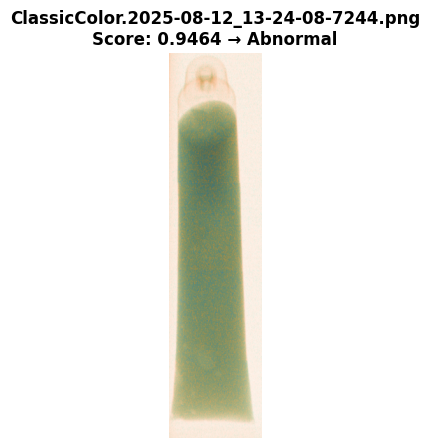

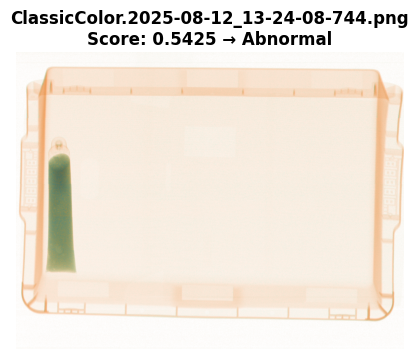

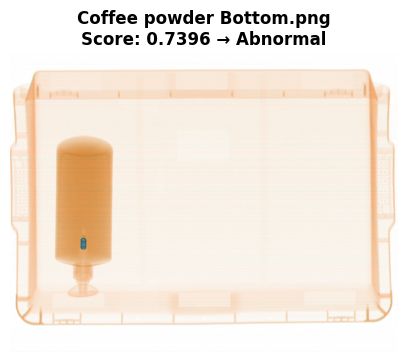

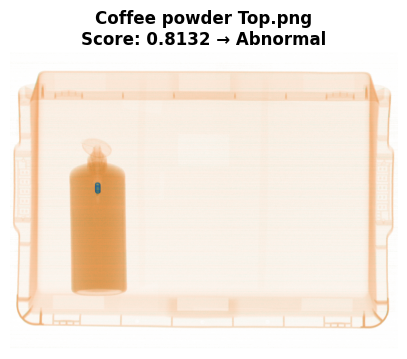

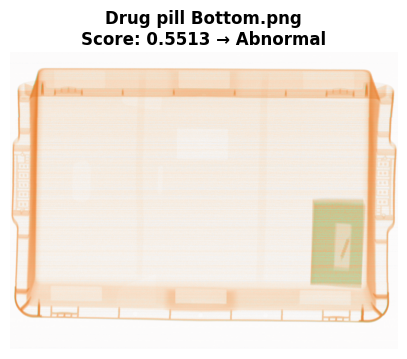

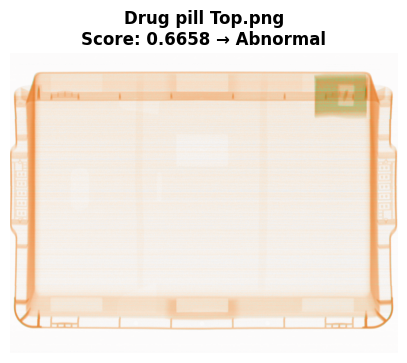

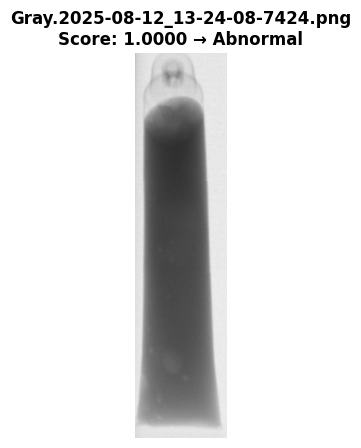

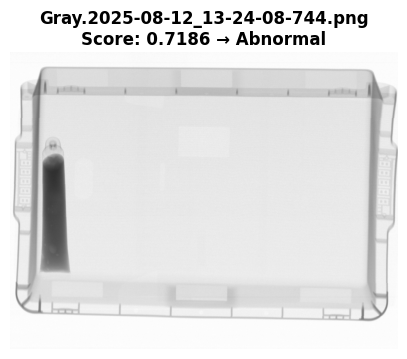

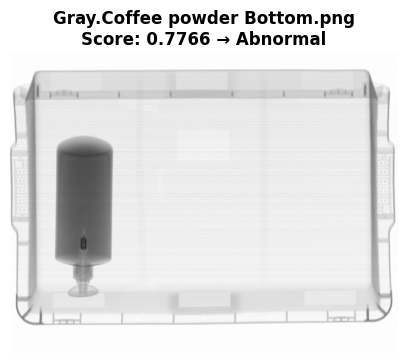

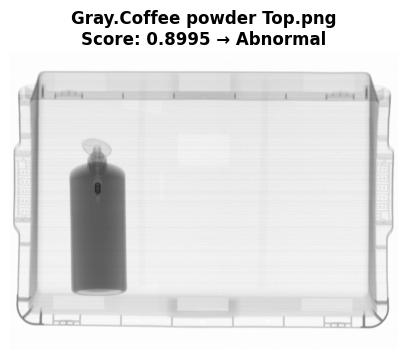

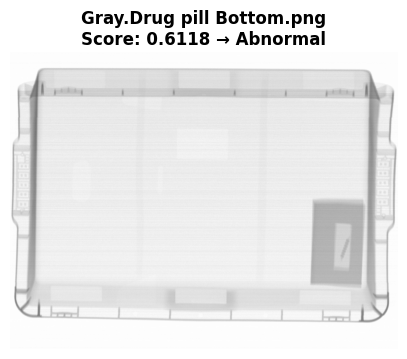

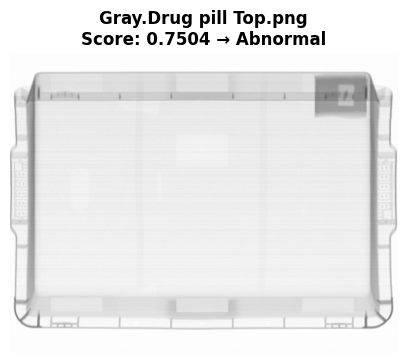

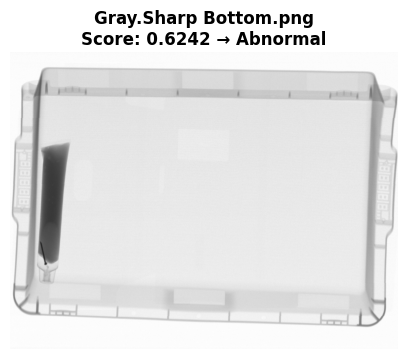

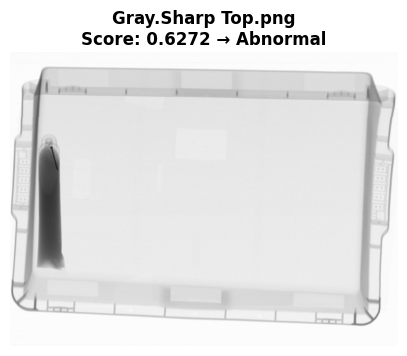

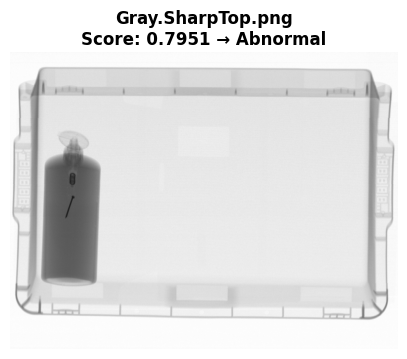

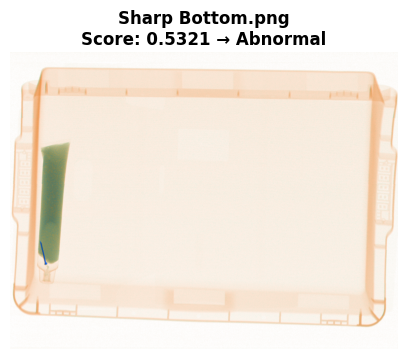

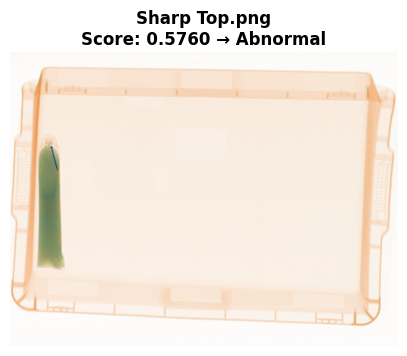

In [ ]:
import torch
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import os

# -------------------------------
# 1️⃣ Device
# -------------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"

# Use your trained model
model = engine.model.to(device)
model.eval()

# -------------------------------
# 2️⃣ Folder containing images
# -------------------------------
image_folder = r"D:\Baggage_XRay\Color"  # change to your folder
threshold = 0.5  # anomaly threshold

transform = transforms.Compose([
    Resize((256, 256)),  # ✅ 一定要固定大小
    ToTensor(),
    Normalize(mean=[0.43, 0.48, 0.45], std=[0.23, 0.22, 0.25]),
])

# -------------------------------
# 3️⃣ Loop through all images in the folder
# -------------------------------
for filename in os.listdir(image_folder):
    if not filename.lower().endswith((".png", ".jpg", ".jpeg", ".bmp")):
        continue

    image_path = os.path.join(image_folder, filename)
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image_tensor)

    # Get image-level anomaly score (tuple output)
    score = outputs[0][0].item()
    prediction = "Abnormal" if score > threshold else "Normal"

    # -------------------------------
    # 4️⃣ Display the image with score
    # -------------------------------
    plt.figure(figsize=(5,5))
    plt.imshow(image)
    plt.title(f"{filename}\nScore: {score:.4f} → {prediction}")
    plt.axis("off")
    plt.show()
